In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Bengaluru_House_Data.csv')

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [5]:
df.shape

(13320, 9)

In [6]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [7]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [8]:
# Drop useless columns
df2 = df.drop(['area_type', 'society', 'availability'], axis='columns')

# Impute balcony (weak feature, moderate missing %) instead of dropping rows
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].median())

# Drop rows only for small, important-column nulls (location, size, bath)
df3 = df2.dropna().copy()

# Convert '2 BHK' / '4 Bedroom' -> 2, 4
df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))

# Inspect total_sqft mess before converting
df3[~df3['total_sqft'].apply(lambda x: x.replace('.','',1).isdigit())].head(10)

,location,size,total_sqft,bath,balcony,price,bhk
30,Yelahanka,4 BHK,2100 - 2850,4.0,0.0,186.000,4
122,Hebbal,4 BHK,3067 - 8156,4.0,0.0,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,0.0,54.005,2
165,Sarjapur,2 BHK,1145 - 1340,2.0,0.0,43.490,2
188,KR Puram,2 BHK,1015 - 1540,2.0,0.0,56.800,2
410,Kengeri,1 BHK,34.46Sq. Meter,1.0,0.0,18.500,1
549,Hennur Road,2 BHK,1195 - 1440,2.0,0.0,63.770,2
648,Arekere,9 Bedroom,4125Perch,9.0,2.0,265.000,9
661,Yelahanka,2 BHK,1120 - 1145,2.0,0.0,48.130,2
672,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,0.0,445.000,4


In [9]:
# what was the median that got used for imputation?
print(df2['balcony'].median())

# how many rows actually have balcony == 0 in the ORIGINAL data (before your dropna/cleaning)?
print((df['balcony'] == 0).sum())

2.0
1029


In [10]:
def convert_sqft(x):
    x = x.strip()

    # Case 1: range like "2100 - 2850"
    if '-' in x:
        tokens = x.split('-')
        try:
            return (float(tokens[0].strip()) + float(tokens[1].strip())) / 2
        except:
            return None

    # Case 2: Sq. Meter -> convert to sqft
    if 'Sq. Meter' in x:
        try:
            num = float(x.replace('Sq. Meter', '').strip())
            return num * 10.7639
        except:
            return None

    # Case 3: unknown/rare units like Perch, Acres, Guntha -> too risky to guess, drop
    try:
        return float(x)
    except:
        return None  # will become NaN, drop later

df3['total_sqft'] = df3['total_sqft'].apply(convert_sqft)

# check how many became NaN (unrecoverable / dropped)
print(df3['total_sqft'].isnull().sum())

df3 = df3.dropna(subset=['total_sqft']).copy()

29


In [11]:
df3.isnull().sum()
df3.shape
df3.dtypes

,0
location,object
size,object
total_sqft,float64
bath,float64
balcony,float64
price,float64
bhk,int64


In [12]:
df3.head()

,location,size,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2


In [13]:
df4 = df3.drop('size', axis='columns').copy()

In [14]:
print(df4.shape)
print(df4.columns)

(13217, 6)
Index(['location', 'total_sqft', 'bath', 'balcony', 'price', 'bhk'], dtype='object')


In [15]:
print(df4.duplicated().sum())
df4 = df4.drop_duplicates().copy()
print(df4.shape)

751
(12466, 6)


In [16]:
df4['location'] = df4['location'].apply(lambda x: x.strip())

In [17]:
print(df4['location'].nunique())

1287


In [18]:
location_counts = df4['location'].value_counts()
rare_locations = location_counts[location_counts <= 10].index
df4['location'] = df4['location'].apply(lambda x: 'other' if x in rare_locations else x)

print(df4['location'].nunique())

232


In [19]:
df4['price_per_sqft'] = df4['price'] * 100000 / df4['total_sqft']

In [20]:
location_counts = df4['location'].value_counts()
rare_locations = location_counts[location_counts <= 10].index
df4['location'] = df4['location'].apply(lambda x: 'other' if x in rare_locations else x)

print(df4['location'].nunique())  # should drop to roughly 240-ish

232


In [21]:
print(df4.columns)
print(df4[['price', 'total_sqft', 'price_per_sqft']].head())

Index(['location', 'total_sqft', 'bath', 'balcony', 'price', 'bhk',
       'price_per_sqft'],
      dtype='object')
    price  total_sqft  price_per_sqft
0   39.07      1056.0     3699.810606
1  120.00      2600.0     4615.384615
2   62.00      1440.0     4305.555556
3   95.00      1521.0     6245.890861
4   51.00      1200.0     4250.000000


In [22]:
# 5a. Remove sqft-per-bhk sanity violations
df5 = df4[~(df4['total_sqft'] / df4['bhk'] < 300)].copy()
print(df5.shape)

# 5b. Remove price_per_sqft outliers, per location
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = subdf.price_per_sqft.mean()
        st = subdf.price_per_sqft.std()
        reduced_df = subdf[(subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df5 = remove_pps_outliers(df5)
print(df5.shape)

(11735, 7)
(9707, 7)


In [23]:
# 5c. Remove bathroom count anomalies
df5 = df5[df5.bath < df5.bhk + 2].copy()
print(df5.shape)

(9608, 7)


In [24]:
df5

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,1st Block Jayanagar,2850.0,4.0,1.0,428.00,4,15017.543860
1,1st Block Jayanagar,1630.0,3.0,2.0,194.00,3,11901.840491
2,1st Block Jayanagar,1875.0,2.0,3.0,235.00,3,12533.333333
3,1st Block Jayanagar,1200.0,2.0,0.0,130.00,3,10833.333333
4,1st Block Jayanagar,1235.0,2.0,2.0,148.00,2,11983.805668
...,...,...,...,...,...,...,...
9702,other,1095.0,2.0,1.0,57.00,2,5205.479452
9703,other,812.0,1.0,0.0,26.00,1,3201.970443
9704,other,1440.0,2.0,2.0,63.93,3,4439.583333
9705,other,1075.0,2.0,2.0,48.00,2,4465.116279


In [25]:
dummies = pd.get_dummies(df5['location'])
df6 = pd.concat([df5, dummies.drop('other', axis='columns')], axis='columns')
df6 = df6.drop('location', axis='columns')
print(df6.shape)
print(df6.columns)

(9608, 237)
Index(['total_sqft', 'bath', 'balcony', 'price', 'bhk', 'price_per_sqft',
       '1st Block Jayanagar', '1st Phase JP Nagar', '2nd Stage Nagarbhavi',
       '5th Block Hbr Layout',
       ...
       'Vijayanagar', 'Vishveshwarya Layout', 'Vishwapriya Layout',
       'Vittasandra', 'Whitefield', 'Yelachenahalli', 'Yelahanka',
       'Yelahanka New Town', 'Yelenahalli', 'Yeshwanthpur'],
      dtype='object', length=237)


In [26]:
df6

,total_sqft,bath,balcony,price,bhk,price_per_sqft,1st Block Jayanagar,1st Phase JP Nagar,2nd Stage Nagarbhavi,5th Block Hbr Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,1.0,428.00,4,15017.543860,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1630.0,3.0,2.0,194.00,3,11901.840491,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1875.0,2.0,3.0,235.00,3,12533.333333,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1200.0,2.0,0.0,130.00,3,10833.333333,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1235.0,2.0,2.0,148.00,2,11983.805668,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9702,1095.0,2.0,1.0,57.00,2,5205.479452,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9703,812.0,1.0,0.0,26.00,1,3201.970443,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9704,1440.0,2.0,2.0,63.93,3,4439.583333,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9705,1075.0,2.0,2.0,48.00,2,4465.116279,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [71]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [34]:
from sklearn.model_selection import train_test_split

X = df6.drop(['price', 'price_per_sqft'], axis='columns')
y = df6['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(7686, 235) (1922, 235)


In [36]:
!pip install xgboost -q

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Check VIF only for the core numeric features (checking all 235 one-hot columns isn't meaningful here)
numeric_cols = ['total_sqft', 'bath', 'balcony', 'bhk']
X_numeric = X[numeric_cols]

vif_data = pd.DataFrame()
vif_data['feature'] = X_numeric.columns
vif_data['VIF'] = [variance_inflation_factor(X_numeric.values, i) for i in range(len(X_numeric.columns))]
print(vif_data)

      feature        VIF
0  total_sqft   7.159459
1        bath  35.661029
2     balcony   4.564182
3         bhk  35.551225


In [50]:
print(X[['total_sqft', 'bath', 'balcony', 'bhk']].corr())

            total_sqft      bath   balcony       bhk
total_sqft    1.000000  0.650813  0.208067  0.634162
bath          0.650813  1.000000  0.248937  0.872572
balcony       0.208067  0.248937  1.000000  0.243567
bhk           0.634162  0.872572  0.243567  1.000000


In [51]:
X_fixed = X.drop('bath', axis='columns')

X_train_fixed, X_test_fixed, y_train_fixed, y_test_fixed = train_test_split(X_fixed, y, test_size=0.2, random_state=42)

lr_fixed = LinearRegression()
lr_fixed.fit(X_train_fixed, y_train_fixed)
print('New R2:', r2_score(y_test_fixed, lr_fixed.predict(X_test_fixed)))

numeric_cols_fixed = ['total_sqft', 'balcony', 'bhk']
vif_data_fixed = pd.DataFrame()
vif_data_fixed['feature'] = numeric_cols_fixed
vif_data_fixed['VIF'] = [variance_inflation_factor(X_fixed[numeric_cols_fixed].values, i) for i in range(len(numeric_cols_fixed))]
print(vif_data_fixed)

New R2: 0.7567618976031697
      feature       VIF
0  total_sqft  6.712859
1     balcony  4.519356
2         bhk  9.770198


In [53]:
coef_df_fixed = pd.DataFrame({
    'feature': X_fixed.columns,
    'coefficient': lr_fixed.coef_
}).sort_values('coefficient', ascending=False)

# Core numeric features
print("Core numeric feature coefficients:")
print(coef_df_fixed[coef_df_fixed['feature'].isin(['total_sqft', 'balcony', 'bhk'])])

# Top / bottom locations
print("\nTop 10 locations by price impact:")
print(coef_df_fixed[~coef_df_fixed['feature'].isin(['total_sqft', 'balcony', 'bhk'])].head(10))

print("\nBottom 10 locations by price impact:")
print(coef_df_fixed[~coef_df_fixed['feature'].isin(['total_sqft', 'balcony', 'bhk'])].tail(10))

# Effective spread comparison — same logic as before, now on cleaner features
sqft_range_fixed = coef_df_fixed[coef_df_fixed['feature']=='total_sqft']['coefficient'].values[0] * X_fixed['total_sqft'].std()
bhk_range_fixed = coef_df_fixed[coef_df_fixed['feature']=='bhk']['coefficient'].values[0] * X_fixed['bhk'].std()
location_coefs_fixed = coef_df_fixed[~coef_df_fixed['feature'].isin(['total_sqft','balcony','bhk'])]['coefficient']
location_range_fixed = location_coefs_fixed.max() - location_coefs_fixed.min()

print(f"\nEffective price spread from total_sqft (1 std dev): ₹{sqft_range_fixed:.2f} lakh")
print(f"Effective price spread from bhk (1 std dev): ₹{bhk_range_fixed:.2f} lakh")
print(f"Effective price spread from location (best vs worst): ₹{location_range_fixed:.2f} lakh")

Core numeric feature coefficients:
      feature  coefficient
2         bhk     1.957650
0  total_sqft     0.069440
1     balcony    -0.890757

Top 10 locations by price impact:
                   feature  coefficient
66         Cunningham Road   465.707246
84              Giri Nagar   236.138571
90           HAL 2nd Stage   227.909515
44             Benson Town   168.880703
190           Rajaji Nagar   158.448316
3      1st Block Jayanagar   141.958960
30   Banashankari Stage II   127.225771
5     2nd Stage Nagarbhavi   122.857838
197          Sarakki Nagar   118.819177
112           Indira Nagar   113.985671

Bottom 10 locations by price impact:
                         feature  coefficient
76                   Dommasandra   -34.828597
208                      Sompura   -34.838023
52   Bommasandra Industrial Area   -38.566787
32          Banashankari Stage V   -38.732127
200    Sarjapura - Attibele Road   -39.068876
225         Vishveshwarya Layout   -40.111984
172                   

In [54]:
df_fixed = X_fixed.copy()
df_fixed['price'] = y

print("Nulls:\n", df_fixed.isnull().sum().sum())
print("Duplicates:", df_fixed.duplicated().sum())

Nulls:
 0
Duplicates: 135


In [55]:
corr_matrix = X_fixed.corr().abs()
high_corr = corr_matrix[(corr_matrix > 0.95) & (corr_matrix < 1.0)]
print(high_corr.stack().drop_duplicates())

Series([], dtype: float64)


Price skew: 6.886089958833798


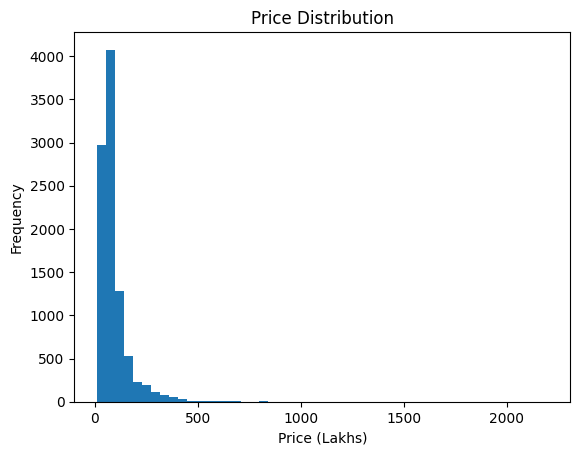

In [56]:
from scipy.stats import skew
import matplotlib.pyplot as plt

print('Price skew:', skew(y))

plt.hist(y, bins=50)
plt.xlabel('Price (Lakhs)')
plt.ylabel('Frequency')
plt.title('Price Distribution')
plt.show()

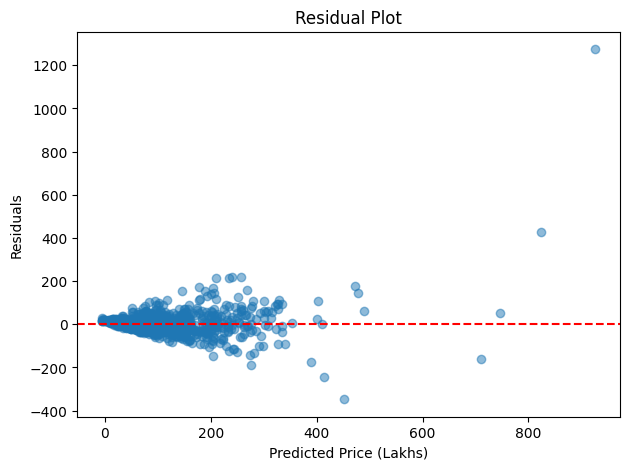

In [57]:
y_pred_fixed = lr_fixed.predict(X_test_fixed)
residuals = y_test_fixed - y_pred_fixed

plt.figure(figsize=(7,5))
plt.scatter(y_pred_fixed, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price (Lakhs)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [59]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LinearRegression(), X_fixed, y, cv=5, scoring='r2')
print('CV scores:', cv_scores)
print(f'Mean: {cv_scores.mean():.3f}, Std: {cv_scores.std():.3f}')

CV scores: [0.53547416 0.67285543 0.59659731 0.78009661 0.72557115]
Mean: 0.662, Std: 0.088


In [60]:
# Update predict_price to use X_fixed's columns (no 'bath' now) and lr_fixed
def predict_price_fixed(location, total_sqft, balcony, bhk):
    x = pd.Series(0, index=X_fixed.columns)
    x['total_sqft'] = total_sqft
    x['balcony'] = balcony
    x['bhk'] = bhk
    if location in X_fixed.columns:
        x[location] = 1
    else:
        print(f"Warning: '{location}' not found, treating as 'other'")
    return lr_fixed.predict(pd.DataFrame([x]))[0]

# Normal case
print(predict_price_fixed('Whitefield', total_sqft=1200, balcony=1, bhk=2))

# Edge cases
print(predict_price_fixed('Whitefield', total_sqft=200, balcony=1, bhk=5))   # tiny sqft, huge bhk
print(predict_price_fixed('Whitefield', total_sqft=10000, balcony=1, bhk=1)) # huge sqft, tiny bhk
print(predict_price_fixed('other', total_sqft=1200, balcony=1, bhk=2))       # unseen/rare location

64.43069331294585
0.8633836474938192
673.5473402840466
73.28553903530509


In [62]:
# Find the specific extreme residual row
extreme_idx = residuals[residuals > 1000].index
print(X_test_fixed.loc[extreme_idx])
print(y_test_fixed.loc[extreme_idx])

      total_sqft  balcony  bhk  1st Block Jayanagar  1st Phase JP Nagar  \
4540     12000.0      3.0    7                False               False   

      2nd Stage Nagarbhavi  5th Block Hbr Layout  5th Phase JP Nagar  \
4540                 False                 False               False   

      6th Phase JP Nagar  7th Phase JP Nagar  ...  Vijayanagar  \
4540               False               False  ...        False   

      Vishveshwarya Layout  Vishwapriya Layout  Vittasandra  Whitefield  \
4540                 False               False        False       False   

      Yelachenahalli  Yelahanka  Yelahanka New Town  Yelenahalli  Yeshwanthpur  
4540           False      False               False        False         False  

[1 rows x 234 columns]
4540    2200.0
Name: price, dtype: float64


In [69]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_fixed, y, test_size=0.2, random_state=42
)

final_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

final_trained = {}
final_results = []
for name, model in final_models.items():
    model.fit(X_train_final, y_train_final)
    final_trained[name] = model
    y_pred = model.predict(X_test_final)
    r2 = r2_score(y_test_final, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_final, y_pred))
    final_results.append({'Model': name, 'R2 Score': r2, 'RMSE': rmse})

final_results_df = pd.DataFrame(final_results).sort_values('R2 Score', ascending=False)
print(final_results_df)

               Model  R2 Score       RMSE
0  Linear Regression  0.756762  44.741413
1              Ridge  0.753111  45.075918
4      Random Forest  0.676969  51.560345
5            XGBoost  0.660771  52.837248
2              Lasso  0.623240  55.683500
3      Decision Tree  0.618238  56.051902


In [70]:
cv_scores_final = cross_val_score(LinearRegression(), X_fixed, y, cv=5, scoring='r2')
print('CV scores:', cv_scores_final)
print(f'Mean: {cv_scores_final.mean():.3f}, Std: {cv_scores_final.std():.3f}')

CV scores: [0.53547416 0.67285543 0.59659731 0.78009661 0.72557115]
Mean: 0.662, Std: 0.088
